# Retrieval Analysis

Reserved for later Top-K retrieval inspection after CLIP/FAISS implementation.


In [1]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content

!git clone https://github.com/nirajj12/Out-of-Context-Multimodal-Misinformation-Detection-Image-Context-Verification.git

%cd /content/Out-of-Context-Multimodal-Misinformation-Detection-Image-Context-Verification

/content
fatal: destination path 'Out-of-Context-Multimodal-Misinformation-Detection-Image-Context-Verification' already exists and is not an empty directory.
/content/Out-of-Context-Multimodal-Misinformation-Detection-Image-Context-Verification


In [3]:
!git pull

remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 8 (delta 3), reused 8 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (8/8), 20.96 KiB | 357.00 KiB/s, done.
From https://github.com/nirajj12/Out-of-Context-Multimodal-Misinformation-Detection-Image-Context-Verification
   be2774f..f043da8  main       -> origin/main
Updating be2774f..f043da8
Fast-forward
 colab/01_clip_embeddings_colab.ipynb      | 2384 ++++++++++++++++++++++++++++-
 colab/02_reranker_experiments_colab.ipynb |   16 +-
 colab/VisualNews_Image_Extraction.ipynb   | 1054 ++++++++++++-
 notebooks/05_retrieval_analysis.ipynb     |   66 +-
 4 files changed, 3466 insertions(+), 54 deletions(-)


In [4]:
try:
    import faiss
    print("FAISS already installed:", faiss.__version__)
except ImportError:
    print("FAISS is not installed")

FAISS already installed: 1.15.1


In [5]:
from pathlib import Path

drive_root = Path("/content/drive/MyDrive/MajorProjectAssets")

embedding_dir = drive_root / "embeddings" / "pilot"
retrieval_output_dir = drive_root / "outputs" / "pilot" / "faiss_retrieval"

retrieval_output_dir.mkdir(parents=True, exist_ok=True)

print("Embedding directory:", embedding_dir)
print("Retrieval output directory:", retrieval_output_dir)

Embedding directory: /content/drive/MyDrive/MajorProjectAssets/embeddings/pilot
Retrieval output directory: /content/drive/MyDrive/MajorProjectAssets/outputs/pilot/faiss_retrieval


In [6]:
required_files = [
    "evidence_image_embeddings.npy",
    "query_image_embeddings.npy",
    "evidence_text_embeddings.npy",
    "query_text_embeddings.npy",
    "evidence_embedding_map.parquet",
    "query_embedding_map.parquet",
    "clip_embedding_config.json",
]

for file_name in required_files:
    file_path = embedding_dir / file_name
    print(file_name, "->", file_path.exists())

evidence_image_embeddings.npy -> True
query_image_embeddings.npy -> True
evidence_text_embeddings.npy -> True
query_text_embeddings.npy -> True
evidence_embedding_map.parquet -> True
query_embedding_map.parquet -> True
clip_embedding_config.json -> True


In [7]:
import numpy as np
import pandas as pd

evidence_image_embeddings = np.load(
    embedding_dir / "evidence_image_embeddings.npy"
)

query_image_embeddings = np.load(
    embedding_dir / "query_image_embeddings.npy"
)

evidence_text_embeddings = np.load(
    embedding_dir / "evidence_text_embeddings.npy"
)

query_text_embeddings = np.load(
    embedding_dir / "query_text_embeddings.npy"
)

evidence_map = pd.read_parquet(
    embedding_dir / "evidence_embedding_map.parquet"
)

query_map = pd.read_parquet(
    embedding_dir / "query_embedding_map.parquet"
)

print("Evidence image:", evidence_image_embeddings.shape)
print("Query image:", query_image_embeddings.shape)
print("Evidence text:", evidence_text_embeddings.shape)
print("Query text:", query_text_embeddings.shape)

print("Evidence map:", len(evidence_map))
print("Query map:", len(query_map))

Evidence image: (5000, 512)
Query image: (200, 512)
Evidence text: (5000, 512)
Query text: (200, 512)
Evidence map: 5000
Query map: 200


In [8]:
pilot_queries = pd.read_parquet(
    "data/manifests/pilot_queries.parquet"
)

pilot_evidence = pd.read_parquet(
    "data/manifests/pilot_evidence.parquet"
)

print("Pilot queries:", len(pilot_queries))
print("Pilot evidence:", len(pilot_evidence))

Pilot queries: 200
Pilot evidence: 5000


## Build Indexes

Continue from the loaded setup objects. CPU `IndexFlatIP` uses inner product on the normalized vectors.

In [9]:
import hashlib
import json
import tempfile
from datetime import datetime, timezone

raw_k = 50
filtered_k = 50
evaluation_ks = [1, 5, 10]
diagnostic_seed = 42
query_count = 200
corpus_size = 5000
embedding_dimension = 512

loaded_arrays = {
    "evidence_image_embeddings.npy": (evidence_image_embeddings, corpus_size),
    "query_image_embeddings.npy": (query_image_embeddings, query_count),
    "evidence_text_embeddings.npy": (evidence_text_embeddings, corpus_size),
    "query_text_embeddings.npy": (query_text_embeddings, query_count),
}
array_checks = []
for filename, (matrix, rows) in loaded_arrays.items():
    assert matrix.shape == (rows, embedding_dimension), f"STOP: {filename} shape mismatch"
    assert matrix.dtype == np.float32, f"STOP: {filename} must be float32"
    assert np.isfinite(matrix).all(), f"STOP: {filename} contains NaNs or Infs"
    norms = np.linalg.norm(matrix, axis=1)
    assert np.allclose(norms, 1.0, atol=1e-5, rtol=0), f"STOP: {filename} is not normalized"
    array_checks.append({
        "array": filename, "shape": list(matrix.shape), "dtype": str(matrix.dtype),
        "min_norm": float(norms.min()), "mean_norm": float(norms.mean()),
        "max_norm": float(norms.max()), "nan_count": 0, "inf_count": 0,
    })
display(pd.DataFrame(array_checks))

,array,shape,dtype,min_norm,mean_norm,max_norm,nan_count,inf_count
0,evidence_image_embeddings.npy,"[5000, 512]",float32,1.0,1.0,1.0,0,0
1,query_image_embeddings.npy,"[200, 512]",float32,1.0,1.0,1.0,0,0
2,evidence_text_embeddings.npy,"[5000, 512]",float32,1.0,1.0,1.0,0,0
3,query_text_embeddings.npy,"[200, 512]",float32,1.0,1.0,1.0,0,0


In [10]:
def require_columns(table, columns, name):
    missing = set(columns) - set(table.columns)
    assert not missing, f"STOP: {name} missing columns: {sorted(missing)}"
    assert not table[columns].isna().any().any(), f"STOP: null values in {name}"

assert len(evidence_map) == len(pilot_evidence) == corpus_size
assert len(query_map) == len(pilot_queries) == query_count
require_columns(evidence_map, ["embedding_row", "evidence_row", "metadata_id", "image_path", "source"], "evidence_map")
require_columns(query_map, ["query_row", "query_id", "image_id", "query_image_path", "matched_image_embedding_row"], "query_map")
require_columns(pilot_queries, ["query_id", "id", "image_id", "query_image_path", "submitted_caption", "falsified", "source_dataset"], "pilot_queries")
require_columns(pilot_evidence, ["id", "image_path", "caption", "source", "is_query_provenance"], "pilot_evidence")
assert evidence_map["embedding_row"].tolist() == list(range(corpus_size))
assert evidence_map["evidence_row"].tolist() == list(range(corpus_size))
assert evidence_map["metadata_id"].tolist() == pilot_evidence["id"].tolist()
assert evidence_map["image_path"].tolist() == pilot_evidence["image_path"].tolist()
assert evidence_map["source"].tolist() == pilot_evidence["source"].tolist()
assert evidence_map["metadata_id"].is_unique and evidence_map["image_path"].is_unique
assert query_map["query_row"].tolist() == list(range(query_count))
for column in ("query_id", "image_id", "query_image_path"):
    assert query_map[column].tolist() == pilot_queries[column].tolist()
matched_image_rows = query_map["matched_image_embedding_row"].to_numpy(dtype=np.int64)
assert ((matched_image_rows >= 0) & (matched_image_rows < corpus_size)).all()
assert evidence_map.iloc[matched_image_rows]["image_path"].tolist() == pilot_queries["query_image_path"].tolist()
assert evidence_map.iloc[matched_image_rows]["metadata_id"].tolist() == pilot_queries["image_id"].tolist()
assert np.array_equal(query_image_embeddings, evidence_image_embeddings[matched_image_rows])
assert pilot_queries["query_id"].is_unique
assert pd.api.types.is_bool_dtype(pilot_queries["falsified"])
assert pd.api.types.is_bool_dtype(pilot_evidence["is_query_provenance"])
print("Loaded matrices, maps, and frozen manifest rows are aligned.")

Loaded matrices, maps, and frozen manifest rows are aligned.


In [11]:
with (embedding_dir / "clip_embedding_config.json").open(encoding="utf-8") as handle:
    clip_config = json.load(handle)
assert clip_config["model_name"] == "ViT-B-32" and clip_config["pretrained"] == "openai"
assert clip_config.get("activation") == "QuickGELU"
assert clip_config.get("force_quick_gelu") is True, "STOP: corrected OpenAI embeddings required"
assert clip_config["embedding_dimension"] == embedding_dimension

manifest_hashes = {}
for name in ("queries", "evidence"):
    manifest_file = Path("data/manifests") / f"pilot_{name}.parquet"
    manifest_hashes[name] = hashlib.sha256(manifest_file.read_bytes()).hexdigest()
    assert manifest_hashes[name] == clip_config["manifest_sha256"][name], "STOP: embedding manifest changed"
input_array_hashes = {}
for filename, (matrix, _) in loaded_arrays.items():
    input_array_hashes[filename] = hashlib.sha256(matrix.tobytes(order="C")).hexdigest()
assert retrieval_output_dir.is_dir()
assert retrieval_output_dir.resolve() != embedding_dir.resolve()
print("Embedding checkpoint and manifest provenance checked; input arrays will remain unchanged.")

Embedding checkpoint and manifest provenance checked; input arrays will remain unchanged.


In [12]:
evidence_image_index = faiss.IndexFlatIP(embedding_dimension)
evidence_text_index = faiss.IndexFlatIP(embedding_dimension)
evidence_image_index.add(np.ascontiguousarray(evidence_image_embeddings))
evidence_text_index.add(np.ascontiguousarray(evidence_text_embeddings))
index_rows = []
for name, index in (("evidence_image", evidence_image_index), ("evidence_text", evidence_text_index)):
    assert index.ntotal == corpus_size and index.d == embedding_dimension
    assert index.metric_type == faiss.METRIC_INNER_PRODUCT
    index_rows.append({"index": name, "type": type(index).__name__, "ntotal": index.ntotal, "dimension": index.d})
print("FAISS:", faiss.__version__, "Device: CPU", "Metric: inner product / cosine")
display(pd.DataFrame(index_rows))

FAISS: 1.15.1 Device: CPU Metric: inner product / cosine


,index,type,ntotal,dimension
0,evidence_image,IndexFlatIP,5000,512
1,evidence_text,IndexFlatIP,5000,512


## Raw Retrieval

Each raw table contains Top-50. Small extra pools refill filtered Top-50 without changing raw ranks.
Text→text is a separate diagnostic channel; scores are never fused.

In [13]:
query_details = pilot_queries[[
    "query_id", "id", "image_id", "query_image_path", "submitted_caption", "falsified", "source_dataset",
]].copy()
query_details = query_details.rename(columns={"id": "caption_id"})
query_details.insert(0, "query_row", np.arange(query_count, dtype=np.int64))
evidence_details = pilot_evidence[["id", "image_path", "caption", "source", "is_query_provenance"]].copy()
evidence_details = evidence_details.rename(columns={
    "id": "evidence_id", "image_path": "evidence_image_path", "caption": "evidence_caption",
    "source": "evidence_source", "is_query_provenance": "is_any_pilot_query_provenance",
})
evidence_details.insert(0, "evidence_row", np.arange(corpus_size, dtype=np.int64))
evidence_rows = evidence_map[["embedding_row", "evidence_row"]].rename(
    columns={"embedding_row": "evidence_embedding_row"},
)
candidate_details = evidence_rows.merge(evidence_details, on="evidence_row", validate="one_to_one", sort=False)
known_duplicate_paths = [
    "visual_news/origin/usa_today/images/0316/125.jpg",
    "visual_news/origin/usa_today/images/0627/512.jpg",
]
assert set(known_duplicate_paths).issubset(set(evidence_map["image_path"]))

In [14]:
def add_candidate_flags(table):
    result = table.copy()
    result["is_exact_query_image_path"] = result["evidence_image_path"].eq(result["query_image_path"])
    result["is_same_image_id"] = result["evidence_id"].eq(result["image_id"])
    result["is_caption_provenance"] = result["evidence_id"].eq(result["caption_id"])
    result["is_query_provenance"] = result["is_same_image_id"] | result["is_caption_provenance"]
    result["is_exact_caption_match"] = result["evidence_caption"].eq(result["submitted_caption"])
    first_query = result["query_image_path"].eq(known_duplicate_paths[0])
    second_query = result["query_image_path"].eq(known_duplicate_paths[1])
    first_candidate = result["evidence_image_path"].eq(known_duplicate_paths[0])
    second_candidate = result["evidence_image_path"].eq(known_duplicate_paths[1])
    result["is_known_exact_duplicate"] = (first_query & second_candidate) | (second_query & first_candidate)
    result["known_duplicate_group"] = pd.Series(pd.NA, index=result.index, dtype="string")
    result.loc[first_candidate | second_candidate, "known_duplicate_group"] = "known_sha256_pair_1"
    return result

def build_result_table(scores, rows, channel):
    assert scores.shape == rows.shape and scores.shape[0] == query_count
    assert np.isfinite(scores).all(), "STOP: nonfinite FAISS scores"
    assert ((rows >= 0) & (rows < corpus_size)).all(), "STOP: invalid FAISS rows"
    pool_size = scores.shape[1]
    table = pd.DataFrame({
        "query_row": np.repeat(np.arange(query_count, dtype=np.int64), pool_size),
        "raw_rank": np.tile(np.arange(1, pool_size + 1, dtype=np.int64), query_count),
        "similarity": scores.ravel(), "evidence_embedding_row": rows.ravel(),
    })
    table = table.merge(query_details, on="query_row", validate="many_to_one", sort=False)
    table = table.merge(candidate_details, on="evidence_embedding_row", validate="many_to_one", sort=False)
    table["retrieval_channel"] = channel
    table = table.sort_values(["query_row", "raw_rank"], kind="stable").reset_index(drop=True)
    assert len(table) == query_count * pool_size
    return add_candidate_flags(table)

In [15]:
caption_counts = pilot_evidence["caption"].value_counts()
exact_caption_counts = pilot_queries["submitted_caption"].map(caption_counts).fillna(0)
max_exact_caption_matches = int(exact_caption_counts.max())
search_pool_sizes = {
    "image_to_image": min(raw_k + 2, corpus_size),
    "image_to_text": raw_k,
    "text_to_text": min(raw_k + max_exact_caption_matches, corpus_size),
}
channel_inputs = {
    "image_to_image": (evidence_image_index, query_image_embeddings),
    "image_to_text": (evidence_text_index, query_image_embeddings),
    "text_to_text": (evidence_text_index, query_text_embeddings),
}
retrieval_pools = {}
raw_results = {}
for channel, (index, query_vectors) in channel_inputs.items():
    scores, rows = index.search(np.ascontiguousarray(query_vectors), search_pool_sizes[channel])
    pool = build_result_table(scores, rows, channel)
    retrieval_pools[channel] = pool
    raw_results[channel] = pool.loc[pool["raw_rank"] <= raw_k].reset_index(drop=True)
    assert len(raw_results[channel]) == query_count * raw_k
    print(f"{channel}: {query_count} queries, raw Top-{raw_k}, search pool {search_pool_sizes[channel]}")
image_to_image_raw = raw_results["image_to_image"]
image_to_text_raw = raw_results["image_to_text"]
text_to_text_raw = raw_results["text_to_text"]

image_to_image: 200 queries, raw Top-50, search pool 52
image_to_text: 200 queries, raw Top-50, search pool 50
text_to_text: 200 queries, raw Top-50, search pool 51


## Filtering

Image→image excludes the query path, its image-side ID, and a known byte-identical counterpart.
Image→text keeps all candidates: image-linked provenance is an intended target, not caption-input leakage.
Text→text excludes verbatim submitted-caption matches. No corpus records are removed or merged.

In [16]:
filtering_rules = {
    "image_to_image": "exclude exact query path OR same image_id OR known byte-identical query counterpart",
    "image_to_text": "no exclusion; retain image-linked provenance and exact caption matches",
    "text_to_text": "exclude evidence caption exactly equal to submitted caption; no text normalization",
}
flag_definitions = {
    "is_exact_query_image_path": "candidate image path exactly equals this query image path",
    "is_caption_provenance": "candidate ID matches this query caption-side id",
    "is_query_provenance": "candidate ID matches this query's image_id or caption-side id",
    "is_any_pilot_query_provenance": "original corpus flag for provenance of any pilot query",
    "is_same_image_id": "candidate ID matches image-side image_id; raw metric target",
    "is_known_exact_duplicate": "candidate is the known byte-identical counterpart of this query image",
    "known_duplicate_group": "both known pair members share a group; never independent visual evidence",
    "is_exact_caption_match": "verbatim evidence-caption equality with submitted query caption",
}

def exclusion_mask(table, channel):
    if channel == "image_to_image":
        return table["is_exact_query_image_path"] | table["is_same_image_id"] | table["is_known_exact_duplicate"]
    if channel == "text_to_text":
        return table["is_exact_caption_match"]
    return pd.Series(False, index=table.index)

filtered_results = {}
for channel, pool in retrieval_pools.items():
    valid = pool.loc[~exclusion_mask(pool, channel)].copy()
    valid["filtered_rank"] = valid.groupby("query_row", sort=False).cumcount() + 1
    filtered = valid.loc[valid["filtered_rank"] <= filtered_k].reset_index(drop=True)
    counts = filtered.groupby("query_row").size().reindex(range(query_count), fill_value=0)
    assert counts.min() >= 10, f"STOP: {channel} has queries with fewer than 10 valid candidates"
    filtered_results[channel] = filtered
    print(f"{channel}: valid candidates per query {counts.min()}–{counts.max()}; raw ranks preserved")
image_to_image_filtered = filtered_results["image_to_image"]
image_to_text_filtered = filtered_results["image_to_text"]
text_to_text_filtered = filtered_results["text_to_text"]

image_to_image: valid candidates per query 50–50; raw ranks preserved
image_to_text: valid candidates per query 50–50; raw ranks preserved
text_to_text: valid candidates per query 50–50; raw ranks preserved


## Metrics

Raw metrics target image-side `image_id`. MRR is truncated at 50: a target absent from raw Top-50 contributes zero.
Filtered tables receive diagnostics, not provenance Recall/MRR. These are not factuality metrics.

In [17]:
flag_columns = [
    "is_exact_query_image_path", "is_same_image_id", "is_caption_provenance",
    "is_query_provenance", "is_exact_caption_match", "is_known_exact_duplicate",
]
required_result_columns = [
    "query_row", "query_id", "caption_id", "image_id", "query_image_path", "submitted_caption",
    "falsified", "source_dataset", "retrieval_channel", "raw_rank", "similarity",
    "evidence_embedding_row", "evidence_row", "evidence_id", "evidence_image_path",
    "evidence_caption", "evidence_source", "is_any_pilot_query_provenance",
] + flag_columns

def validate_candidate_metadata(table):
    query_rows = table["query_row"].to_numpy(dtype=np.int64)
    evidence_rows = table["evidence_embedding_row"].to_numpy(dtype=np.int64)
    assert ((query_rows >= 0) & (query_rows < query_count)).all()
    assert ((evidence_rows >= 0) & (evidence_rows < corpus_size)).all()
    expected_queries = query_details.iloc[query_rows]
    expected_candidates = candidate_details.set_index("evidence_embedding_row").loc[evidence_rows]
    for column in ("query_id", "caption_id", "image_id", "query_image_path", "submitted_caption", "falsified", "source_dataset"):
        assert table[column].tolist() == expected_queries[column].tolist(), f"STOP: query {column} misaligned"
    for column in ("evidence_row", "evidence_id", "evidence_image_path", "evidence_caption", "evidence_source", "is_any_pilot_query_provenance"):
        assert table[column].tolist() == expected_candidates[column].tolist(), f"STOP: evidence {column} misaligned"

In [18]:
def validate_result_ranks(table, channel, filtered):
    rank_column = "filtered_rank" if filtered else "raw_rank"
    assert rank_column in table.columns
    assert set(table["query_row"]) == set(range(query_count))
    assert set(table["retrieval_channel"]) == {channel}
    for column in ("query_row", "raw_rank", "evidence_embedding_row", "evidence_row", rank_column):
        assert pd.api.types.is_integer_dtype(table[column]), f"STOP: invalid integer column {column}"
    assert not table.duplicated(["query_row", rank_column]).any()
    assert not table.duplicated(["query_row", "evidence_embedding_row"]).any()
    rank_limit = search_pool_sizes[channel] if filtered else raw_k
    assert table["raw_rank"].between(1, rank_limit).all()
    counts = table.groupby("query_row").size()
    if filtered:
        assert counts.min() >= 10 and counts.max() <= filtered_k
        assert not exclusion_mask(table, channel).any()
    else:
        assert (counts == raw_k).all()
    for _, group in table.groupby("query_row", sort=False):
        assert group[rank_column].tolist() == list(range(1, len(group) + 1))
        assert group["raw_rank"].is_monotonic_increasing
        assert (group["similarity"].diff().fillna(0) <= 1e-6).all()


def validate_result_table(table, channel, filtered=False):
    require_columns(table, required_result_columns, channel)
    assert "known_duplicate_group" in table.columns
    assert np.isfinite(table["similarity"].to_numpy()).all()
    assert table["similarity"].between(-1.00001, 1.00001).all()
    validate_candidate_metadata(table)
    validate_result_ranks(table, channel, filtered)
    expected_flags = add_candidate_flags(table)
    for column in flag_columns + ["known_duplicate_group"]:
        pd.testing.assert_series_equal(table[column], expected_flags[column], check_dtype=False)
    return {
        "channel": channel, "version": "filtered" if filtered else "raw", "rows": len(table),
        "queries": table["query_row"].nunique(),
        "min_candidates": int(table.groupby("query_row").size().min()),
        "max_candidates": int(table.groupby("query_row").size().max()),
    }

In [19]:
result_validation = []
for channel in channel_inputs:
    result_validation.append(validate_result_table(raw_results[channel], channel))
    result_validation.append(validate_result_table(filtered_results[channel], channel, filtered=True))
display(pd.DataFrame(result_validation))


def provenance_rank_rows(raw_table):
    hits = raw_table.loc[raw_table["evidence_id"].eq(raw_table["image_id"]), ["query_row", "raw_rank"]]
    assert hits["query_row"].is_unique
    rank_lookup = hits.set_index("query_row")["raw_rank"]
    diagnostics = query_details[["query_row", "query_id", "image_id", "falsified", "source_dataset"]].copy()
    diagnostics["target_raw_rank"] = diagnostics["query_row"].map(rank_lookup).fillna(0).astype(np.int64)
    diagnostics["reciprocal_rank"] = 0.0
    found = diagnostics["target_raw_rank"] > 0
    diagnostics.loc[found, "reciprocal_rank"] = 1.0 / diagnostics.loc[found, "target_raw_rank"]
    return diagnostics


def raw_provenance_metrics(diagnostics):
    assert not diagnostics.empty
    ranks = diagnostics["target_raw_rank"]
    metrics = {"query_count": len(diagnostics)}
    for k in evaluation_ks:
        metrics[f"recall_at_{k}"] = float(((ranks > 0) & (ranks <= k)).mean())
    metrics["mrr"] = float(diagnostics["reciprocal_rank"].mean())
    metrics["mrr_cutoff"] = raw_k
    metrics["targets_absent_from_raw_top_50"] = int((ranks == 0).sum())
    return metrics

,channel,version,rows,queries,min_candidates,max_candidates
0,image_to_image,raw,10000,200,50,50
1,image_to_image,filtered,10000,200,50,50
2,image_to_text,raw,10000,200,50,50
3,image_to_text,filtered,10000,200,50,50
4,text_to_text,raw,10000,200,50,50
5,text_to_text,filtered,10000,200,50,50


In [20]:
per_query_diagnostics = {}
raw_metrics = {}
stratified_metrics = {}
raw_metric_rows = []
stratified_rows = []
for channel, raw_table in raw_results.items():
    diagnostics = provenance_rank_rows(raw_table)
    per_query_diagnostics[channel] = diagnostics
    raw_metrics[channel] = raw_provenance_metrics(diagnostics)
    raw_metric_rows.append({"channel": channel, **raw_metrics[channel]})
    strata = {
        "pristine": diagnostics.loc[~diagnostics["falsified"]],
        "falsified": diagnostics.loc[diagnostics["falsified"]],
    }
    falsified_rows = diagnostics.loc[diagnostics["falsified"]]
    for source_category in sorted(falsified_rows["source_dataset"].unique()):
        group_name = f"falsified/source_dataset={source_category}"
        strata[group_name] = falsified_rows.loc[falsified_rows["source_dataset"] == source_category]
    stratified_metrics[channel] = {}
    for group_name, group in strata.items():
        group_metrics = raw_provenance_metrics(group)
        stratified_metrics[channel][group_name] = group_metrics
        stratified_rows.append({"channel": channel, "group": group_name, **group_metrics})
display(pd.DataFrame(raw_metric_rows).round(5))
display(pd.DataFrame(stratified_rows).round(5))

,channel,query_count,recall_at_1,recall_at_5,recall_at_10,mrr,mrr_cutoff,targets_absent_from_raw_top_50
0,image_to_image,200,1.00,1.00,1.000,1.00000,50,0
1,image_to_text,200,0.58,0.78,0.870,0.67500,50,8
2,text_to_text,200,0.50,0.66,0.715,0.57559,50,42


,channel,group,query_count,recall_at_1,recall_at_5,recall_at_10,mrr,mrr_cutoff,targets_absent_from_raw_top_50
0,image_to_image,pristine,100,1.00,1.00,1.00,1.00000,50,0
1,image_to_image,falsified,100,1.00,1.00,1.00,1.00000,50,0
2,image_to_image,falsified/source_dataset=0,25,1.00,1.00,1.00,1.00000,50,0
3,image_to_image,falsified/source_dataset=1,25,1.00,1.00,1.00,1.00000,50,0
4,image_to_image,falsified/source_dataset=2,25,1.00,1.00,1.00,1.00000,50,0
5,image_to_image,falsified/source_dataset=3,25,1.00,1.00,1.00,1.00000,50,0
6,image_to_text,pristine,100,0.55,0.76,0.83,0.65527,50,5
7,image_to_text,falsified,100,0.61,0.80,0.91,0.69473,50,3
8,image_to_text,falsified/source_dataset=0,25,0.52,0.80,0.88,0.63474,50,1
9,image_to_text,falsified/source_dataset=1,25,0.80,0.96,1.00,0.87111,50,0


In [21]:
def score_summary(table, rank_column):
    top_one = table.loc[table[rank_column] == 1, "similarity"]
    return {
        "top_1_mean": float(top_one.mean()), "top_1_median": float(top_one.median()),
        "top_1_min": float(top_one.min()), "top_1_max": float(top_one.max()),
        "top_5_average": float(table.loc[table[rank_column] <= 5, "similarity"].mean()),
        "top_10_average": float(table.loc[table[rank_column] <= 10, "similarity"].mean()),
    }


def filtered_diagnostics(channel):
    raw_table = raw_results[channel]
    pool = retrieval_pools[channel]
    filtered = filtered_results[channel]
    counts = filtered.groupby("query_row").size().reindex(range(query_count), fill_value=0)
    return {
        "query_count": query_count, "filtered_candidate_rows": len(filtered),
        "raw_candidates_excluded_by_rule": int(exclusion_mask(raw_table, channel).sum()),
        "pool_candidates_excluded_by_rule": int(exclusion_mask(pool, channel).sum()),
        "refill_rows_from_beyond_raw_top_50": int((filtered["raw_rank"] > raw_k).sum()),
        "min_candidates_per_query": int(counts.min()), "max_candidates_per_query": int(counts.max()),
        "queries_with_top_10": int((counts >= 10).sum()), "queries_with_top_50": int((counts >= 50).sum()),
        "exact_query_path_matches_in_raw": int(raw_table["is_exact_query_image_path"].sum()),
        "same_image_id_matches_in_raw": int(raw_table["is_same_image_id"].sum()),
        "query_linked_duplicate_matches_in_raw": int(raw_table["is_known_exact_duplicate"].sum()),
        "provenance_recall_not_evaluated_after_filtering": True,
    }

score_rows = []
filtered_diagnostic_rows = []
for channel in channel_inputs:
    score_rows.append({"channel": channel, "version": "raw", **score_summary(raw_results[channel], "raw_rank")})
    score_rows.append({"channel": channel, "version": "filtered", **score_summary(filtered_results[channel], "filtered_rank")})
    filtered_diagnostic_rows.append({"channel": channel, **filtered_diagnostics(channel)})
display(pd.DataFrame(score_rows).round(5))
display(pd.DataFrame(filtered_diagnostic_rows))

,channel,version,top_1_mean,top_1_median,top_1_min,top_1_max,top_5_average,top_10_average
0,image_to_image,raw,1.00000,1.00000,1.00000,1.00000,0.80741,0.76236
1,image_to_image,filtered,0.78718,0.78561,0.52952,0.97148,0.75335,0.73259
2,image_to_text,raw,0.32582,0.32141,0.25500,0.42722,0.29557,0.28288
3,image_to_text,filtered,0.32582,0.32141,0.25500,0.42722,0.29557,0.28288
4,text_to_text,raw,1.00000,1.00000,1.00000,1.00000,0.74904,0.69600
5,text_to_text,filtered,0.71992,0.71534,0.39541,0.94323,0.67994,0.65900


,channel,query_count,filtered_candidate_rows,raw_candidates_excluded_by_rule,pool_candidates_excluded_by_rule,refill_rows_from_beyond_raw_top_50,min_candidates_per_query,max_candidates_per_query,queries_with_top_10,queries_with_top_50,exact_query_path_matches_in_raw,same_image_id_matches_in_raw,query_linked_duplicate_matches_in_raw,provenance_recall_not_evaluated_after_filtering
0,image_to_image,200,10000,200,200,200,50,50,200,200,200,200,0,True
1,image_to_text,200,10000,0,0,0,50,50,200,200,192,192,0,True
2,text_to_text,200,10000,200,200,200,50,50,200,200,158,158,0,True


In [22]:
path_to_embedding_row = evidence_map.set_index("image_path")["embedding_row"]
duplicate_rows = path_to_embedding_row.loc[known_duplicate_paths].to_numpy(dtype=np.int64)
duplicate_cosine = float(np.dot(
    evidence_image_embeddings[duplicate_rows[0]], evidence_image_embeddings[duplicate_rows[1]],
))
assert np.isclose(duplicate_cosine, 1.0, atol=1e-5, rtol=0), "STOP: known duplicate embeddings disagree"
print("Known duplicate image rows:", duplicate_rows.tolist(), "cosine:", duplicate_cosine)


def duplicate_diagnostics(table):
    pair_rows = table.loc[table["evidence_image_path"].isin(known_duplicate_paths)]
    pair_counts = pair_rows.groupby("query_row")["evidence_image_path"].nunique()
    return {
        "known_pair_candidate_rows": len(pair_rows),
        "queries_with_either_pair_member": len(pair_counts),
        "queries_with_both_pair_members": int((pair_counts == 2).sum()),
        "query_linked_counterpart_flags": int(table["is_known_exact_duplicate"].sum()),
    }

duplicate_summary_rows = []
for channel in channel_inputs:
    for version, tables in (("raw", raw_results), ("filtered", filtered_results)):
        duplicate_summary_rows.append({"channel": channel, "version": version, **duplicate_diagnostics(tables[channel])})
display(pd.DataFrame(duplicate_summary_rows))
print("Both pair records stay in the corpus; their shared group marks them as one underlying image for later evidence assessment.")

Known duplicate image rows: [2025, 1540] cosine: 1.0


,channel,version,known_pair_candidate_rows,queries_with_either_pair_member,queries_with_both_pair_members,query_linked_counterpart_flags
0,image_to_image,raw,8,4,4,0
1,image_to_image,filtered,8,4,4,0
2,image_to_text,raw,3,3,0,0
3,image_to_text,filtered,3,3,0,0
4,text_to_text,raw,4,4,0,0
5,text_to_text,filtered,4,4,0,0


Both pair records stay in the corpus; their shared group marks them as one underlying image for later evidence assessment.


## Examples

Seed 42 selects one falsified query per construction category and two pristine queries.
Inspect captions and thumbnails across channels; do not assign event or factuality labels.

In [23]:
sampler = np.random.default_rng(diagnostic_seed)
sample_query_rows = []
source_categories = sorted(query_details["source_dataset"].unique())
for source_category in source_categories:
    candidates = query_details.loc[
        query_details["falsified"] & query_details["source_dataset"].eq(source_category), "query_row",
    ]
    if not candidates.empty:
        sample_query_rows.append(int(sampler.choice(candidates.to_numpy())))
for source_category in source_categories[:2]:
    candidates = query_details.loc[
        ~query_details["falsified"] & query_details["source_dataset"].eq(source_category), "query_row",
    ]
    if not candidates.empty:
        sample_query_rows.append(int(sampler.choice(candidates.to_numpy())))
sample_query_rows = sorted(set(sample_query_rows))
example_columns = [
    "retrieval_channel", "raw_rank", "filtered_rank", "evidence_id", "evidence_image_path",
    "evidence_caption", "evidence_source", "similarity", "is_exact_query_image_path",
    "is_same_image_id", "is_query_provenance", "is_known_exact_duplicate", "known_duplicate_group",
]
for query_row in sample_query_rows:
    print("Query row:", query_row)
    display(query_details.loc[query_details["query_row"] == query_row].drop(columns="caption_id"))
    samples = []
    for channel in channel_inputs:
        candidates = filtered_results[channel]
        samples.append(candidates.loc[candidates["query_row"].eq(query_row) & candidates["filtered_rank"].le(3), example_columns])
    with pd.option_context("display.max_colwidth", 100):
        display(pd.concat(samples, ignore_index=True).round({"similarity": 5}))

Query row: 10


,query_row,query_id,image_id,query_image_path,submitted_caption,falsified,source_dataset
10,10,Q0011,151594,visual_news/origin/washington_post/images/0401...,Armin Van Buuren performs at FUR Nightclub whi...,False,0


,retrieval_channel,raw_rank,filtered_rank,evidence_id,evidence_image_path,evidence_caption,evidence_source,similarity,is_exact_query_image_path,is_same_image_id,is_query_provenance,is_known_exact_duplicate,known_duplicate_group
0,image_to_image,2,1,126920,visual_news/origin/washington_post/images/0237/776.jpg,A concert at Linternational in Paris,washington_post,0.75632,False,False,False,False,<NA>
1,image_to_image,3,2,200611,visual_news/origin/washington_post/images/0553/017.jpg,Macaulay Culkin of the Pizza Underground hands out pizza to fans during the group s performance ...,washington_post,0.70533,False,False,False,False,<NA>
2,image_to_image,4,3,295018,visual_news/origin/usa_today/images/0475/986.jpg,Fans have fun in the infield before the 141st running of the Kentucky Derby,usa_today,0.68050,False,False,False,False,<NA>
3,image_to_text,1,1,151594,visual_news/origin/washington_post/images/0401/627.jpg,Armin Van Buuren performs at FUR Nightclub which was sold to Skanska,washington_post,0.31183,True,True,True,False,<NA>
4,image_to_text,2,2,126920,visual_news/origin/washington_post/images/0237/776.jpg,A concert at Linternational in Paris,washington_post,0.27256,False,False,False,False,<NA>
5,image_to_text,3,3,1620144,visual_news/origin/bbc/images/0334/353.jpg,The new bar will be located in the Roppongi area of Tokyo,bbc,0.25709,False,False,False,False,<NA>
6,text_to_text,2,1,949344,visual_news/origin/guardian/images/0158/806.jpg,Dutch farright Freedom party leader Geert Wilders is accused of discrimination and inciting hatred,guardian,0.58384,False,False,False,False,<NA>
7,text_to_text,3,2,1587757,visual_news/origin/bbc/images/0358/979.jpg,Host Graham Norton is at the top of his game said producer Jon Magnusson,bbc,0.57577,False,False,False,False,<NA>
8,text_to_text,4,3,1604043,visual_news/origin/bbc/images/0296/457.jpg,Collins verbally abused and physically assaulted his former lover Anna Larke,bbc,0.57409,False,False,False,False,<NA>


Query row: 46


,query_row,query_id,image_id,query_image_path,submitted_caption,falsified,source_dataset
46,46,Q0047,111118,visual_news/origin/washington_post/images/0507...,This video image shows El Chapo being escorted...,False,1


...

,query_row,query_id,image_id,query_image_path,submitted_caption,falsified,source_dataset
166,166,Q0167,288678,visual_news/origin/usa_today/images/0673/877.jpg,The sun rises above Haleakala National Park in...,True,2


,retrieval_channel,raw_rank,filtered_rank,evidence_id,evidence_image_path,evidence_caption,evidence_source,similarity,is_exact_query_image_path,is_same_image_id,is_query_provenance,is_known_exact_duplicate,known_duplicate_group
0,image_to_image,2,1,415169,visual_news/origin/usa_today/images/0673/845.jpg,Colorado sunrise The sky blazes orange just before the sun rises south of Denver last week The p...,usa_today,0.82734,False,False,False,False,<NA>
1,image_to_image,3,2,80888,visual_news/origin/washington_post/images/0335/412.jpg,The colors of the sunset and flora of the African savannah afford a unique background for the pl...,washington_post,0.80157,False,False,False,False,<NA>
2,image_to_image,4,3,336106,visual_news/origin/usa_today/images/0590/091.jpg,The sun rises above Haleakala National Park in Maui Hawaii,usa_today,0.79822,False,False,True,False,<NA>
3,image_to_text,1,1,288678,visual_news/origin/usa_today/images/0673/877.jpg,Nevada sunset Lenticular clouds pile up over Virginia City Nev at sunset last year,usa_today,0.36357,True,True,True,False,<NA>
4,image_to_text,2,2,415169,visual_news/origin/usa_today/images/0673/845.jpg,Colorado sunrise The sky blazes orange just before the sun rises south of Denver last week The p...,usa_today,0.26431,False,False,False,False,<NA>
5,image_to_text,3,3,730662,visual_news/origin/guardian/images/0547/437.jpg,The fire started on Friday afternoon near a highway on the border of Inyo and Mono counties,guardian,0.25785,False,False,False,False,<NA>
6,text_to_text,2,1,415169,visual_news/origin/usa_today/images/0673/845.jpg,Colorado sunrise The sky blazes orange just before the sun rises south of Denver last week The p...,usa_today,0.49172,False,False,False,False,<NA>
7,text_to_text,3,2,278153,visual_news/origin/usa_today/images/0599/500.jpg,At the heart of Honolulu sits Waikiki Beach former playground to Hawaiian royalty and home of a ...,usa_today,0.47186,False,False,False,False,<NA>
8,text_to_text,4,3,220978,visual_news/origin/usa_today/images/0654/656.jpg,A sunrise colors Tunnel View in Yosemite National Park Calif on March 17 2015,usa_today,0.46755,False,False,False,False,<NA>


Query row: 185


,query_row,query_id,image_id,query_image_path,submitted_caption,falsified,source_dataset
185,185,Q0186,51090,visual_news/origin/washington_post/images/0577...,On the campaign trail in Minneapolis Hillary C...,True,3


,retrieval_channel,raw_rank,filtered_rank,evidence_id,evidence_image_path,evidence_caption,evidence_source,similarity,is_exact_query_image_path,is_same_image_id,is_query_provenance,is_known_exact_duplicate,known_duplicate_group
0,image_to_image,2,1,48132,visual_news/origin/washington_post/images/0557/751.jpg,Hillary Clinton speaks to her supporters during her Primary Night Event at the Palm Beach County...,washington_post,0.92165,False,False,False,False,<NA>
1,image_to_image,3,2,161071,visual_news/origin/washington_post/images/0254/321.jpg,Come November if the electoral college ties it would be nearly impossible for Hillary Clinton to...,washington_post,0.91754,False,False,False,False,<NA>
2,image_to_image,4,3,103433,visual_news/origin/washington_post/images/0539/013.jpg,Former secretary of state Hillary Clinton speaks to supporters during a rally at the Fillmore Ph...,washington_post,0.91247,False,False,False,False,<NA>
3,image_to_text,1,1,1525843,visual_news/origin/bbc/images/0140/302.jpg,On the campaign trail in Minneapolis Hillary Clinton condemned her Republican rivals,bbc,0.31357,False,False,True,False,<NA>
4,image_to_text,2,2,416346,visual_news/origin/usa_today/images/0083/518.jpg,Democratic presidential candidate Hillary Clinton was barely ahead of Bernie Sanders late Monday...,usa_today,0.30821,False,False,False,False,<NA>
5,image_to_text,3,3,1246595,visual_news/origin/guardian/images/0060/622.jpg,Hillary Clinton speaks in Iowa City this week,guardian,0.30533,False,False,False,False,<NA>
6,text_to_text,2,1,1246595,visual_news/origin/guardian/images/0060/622.jpg,Hillary Clinton speaks in Iowa City this week,guardian,0.86179,False,False,False,False,<NA>
7,text_to_text,3,2,416346,visual_news/origin/usa_today/images/0083/518.jpg,Democratic presidential candidate Hillary Clinton was barely ahead of Bernie Sanders late Monday...,usa_today,0.84216,False,False,False,False,<NA>
8,text_to_text,4,3,155842,visual_news/origin/washington_post/images/0109/334.jpg,Hillary Clinton campaigns in Vinton Iowa on Thursday,washington_post,0.83997,False,False,False,False,<NA>



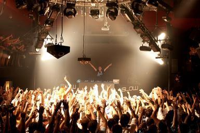
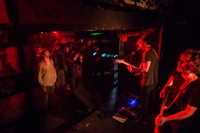
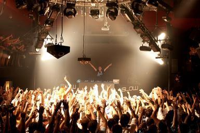


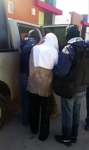
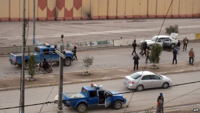
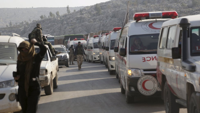


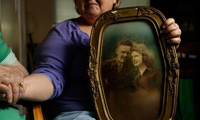
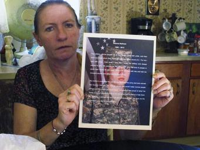
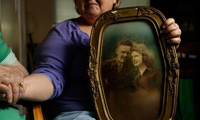


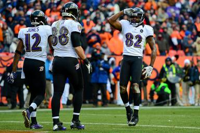
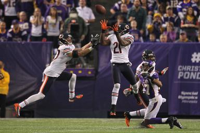
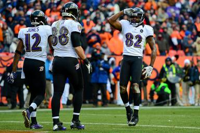


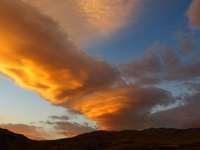
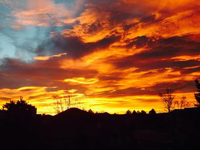
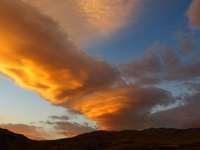


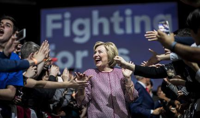
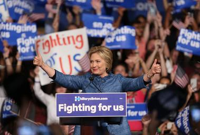
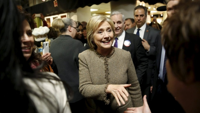

In [24]:
from base64 import b64encode
from html import escape
from io import BytesIO
from pathlib import PurePosixPath
from IPython.display import HTML, display
from PIL import Image

preview_image_root = Path(clip_config["image_root"])

def image_preview(image_path, label):
    relative = PurePosixPath(image_path)
    assert not relative.is_absolute() and ".." not in relative.parts
    with Image.open(preview_image_root.joinpath(*relative.parts)) as image:
        preview = image.convert("RGB")
        preview.thumbnail((200, 150))
    buffer = BytesIO()
    preview.save(buffer, format="PNG")
    encoded = b64encode(buffer.getvalue()).decode("ascii")
    return (
        '<div style="width:220px;flex-shrink:0">'
        f'<strong>{escape(label)}</strong><br>'
        f'<img src="data:image/png;base64,{encoded}" alt="{escape(label)}"><br>'
        f'<small>{escape(image_path)}</small></div>'
    )

for query_row in sample_query_rows:
    query = query_details.iloc[query_row]
    panels = [image_preview(query["query_image_path"], f"Query {query['query_id']}")]
    for channel in ("image_to_image", "image_to_text"):
        table = filtered_results[channel]
        candidate = table.loc[table["query_row"].eq(query_row) & table["filtered_rank"].eq(1)].iloc[0]
        panels.append(image_preview(candidate["evidence_image_path"], f"{channel} filtered #1"))
    display(HTML('<div style="display:flex;gap:12px;overflow:auto">' + ''.join(panels) + '</div>'))

## Save

Run these cells manually after reviewing the diagnostics. They write only to `retrieval_output_dir`.
Each artifact is written to a temporary file, checked, replaced, and reloaded; a failure stops the stage.

In [25]:
def verify_frozen_inputs():
    for filename, (matrix, _) in loaded_arrays.items():
        digest = hashlib.sha256(matrix.tobytes(order="C")).hexdigest()
        assert digest == input_array_hashes[filename], f"STOP: input array changed: {filename}"
    for name, expected_digest in manifest_hashes.items():
        path = Path("data/manifests") / f"pilot_{name}.parquet"
        assert hashlib.sha256(path.read_bytes()).hexdigest() == expected_digest

verify_frozen_inputs()
retrieval_metrics = {}
for channel in channel_inputs:
    retrieval_metrics[channel] = {
        "raw": raw_metrics[channel],
        "raw_stratified": stratified_metrics[channel],
        "filtered_diagnostics": filtered_diagnostics(channel),
        "raw_score_summary": score_summary(raw_results[channel], "raw_rank"),
        "filtered_score_summary": score_summary(filtered_results[channel], "filtered_rank"),
        "raw_known_pair_diagnostics": duplicate_diagnostics(raw_results[channel]),
        "filtered_known_pair_diagnostics": duplicate_diagnostics(filtered_results[channel]),
    }
retrieval_metrics["evaluation_semantics"] = {
    "target": "image-side image_id, not caption-side id",
    "mrr": "MRR@50; absent raw Top-50 targets contribute zero",
    "filtered": "diagnostics only; no filtered provenance Recall or MRR",
    "interpretation": "candidate retrieval only; similarity is not factuality or event ground truth",
    "known_pair_image_cosine": duplicate_cosine,
}

In [26]:
retrieval_config = {
    "faiss_version": faiss.__version__, "index_type": "IndexFlatIP", "device": "CPU",
    "metric_type": "inner_product", "normalized_vectors": True, "normalization_atol": 1e-5,
    "evidence_corpus_size": corpus_size, "query_count": query_count,
    "embedding_dimension": embedding_dimension, "raw_k": raw_k, "filtered_k": filtered_k,
    "search_pool_sizes": search_pool_sizes, "evaluation_ks": evaluation_ks, "mrr_cutoff": raw_k,
    "provenance_target": "image_id", "filtering_rules": filtering_rules,
    "flag_definitions": flag_definitions, "embedding_directory": str(embedding_dir),
    "retrieval_output_directory": str(retrieval_output_dir),
    "input_embedding_file_names": required_files, "seed": diagnostic_seed,
    "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    "embedding_model": {"model_name": clip_config["model_name"], "pretrained": clip_config["pretrained"],
                        "activation": clip_config["activation"], "force_quick_gelu": True},
    "manifest_sha256": manifest_hashes, "input_array_content_sha256": input_array_hashes,
    "known_duplicate_paths": known_duplicate_paths, "known_duplicate_records_retained": True,
    "diagnostic_query_rows": sample_query_rows,
    "diagnostic_fields": "falsified and source_dataset used only after search; no score fusion",
    "source_dataset_semantics": "mismatch construction strategy, not truthfulness",
    "tie_handling": "FAISS candidate order preserved; no claim of a unique ordering for equal scores",
}
print("Prepared metrics and config in memory. No output files written by this cell.")

Prepared metrics and config in memory. No output files written by this cell.


In [27]:
def temporary_output_path(final_path):
    assert final_path.parent == retrieval_output_dir
    handle = tempfile.NamedTemporaryFile(
        dir=final_path.parent, prefix=f".{final_path.name}.", suffix=".tmp", delete=False,
    )
    handle.close()
    return Path(handle.name)


def save_result_table(filename, table, channel, filtered):
    final_path = retrieval_output_dir / filename
    temporary_path = temporary_output_path(final_path)
    try:
        table.to_parquet(temporary_path, index=False)
        temporary_table = pd.read_parquet(temporary_path)
        pd.testing.assert_frame_equal(table, temporary_table, check_dtype=False)
        validate_result_table(temporary_table, channel, filtered)
        temporary_path.replace(final_path)
        reloaded = pd.read_parquet(final_path)
        pd.testing.assert_frame_equal(table, reloaded, check_dtype=False)
        validate_result_table(reloaded, channel, filtered)
        return reloaded
    finally:
        temporary_path.unlink(missing_ok=True)

In [28]:
def validate_saved_index(index, expected_vectors):
    assert isinstance(index, faiss.IndexFlatIP)
    assert index.ntotal == corpus_size and index.d == embedding_dimension
    assert index.metric_type == faiss.METRIC_INNER_PRODUCT
    stored_vectors = index.reconstruct_n(0, corpus_size)
    assert np.array_equal(stored_vectors, expected_vectors), "STOP: saved index vectors changed"


def save_index(filename, index, expected_vectors):
    final_path = retrieval_output_dir / filename
    temporary_path = temporary_output_path(final_path)
    try:
        faiss.write_index(index, str(temporary_path))
        validate_saved_index(faiss.read_index(str(temporary_path)), expected_vectors)
        temporary_path.replace(final_path)
        reloaded = faiss.read_index(str(final_path))
        validate_saved_index(reloaded, expected_vectors)
        return reloaded
    finally:
        temporary_path.unlink(missing_ok=True)


def save_json(filename, contents):
    final_path = retrieval_output_dir / filename
    temporary_path = temporary_output_path(final_path)
    try:
        with temporary_path.open("w", encoding="utf-8") as handle:
            json.dump(contents, handle, indent=2, allow_nan=False)
        with temporary_path.open(encoding="utf-8") as handle:
            assert json.load(handle) == contents
        temporary_path.replace(final_path)
        with final_path.open(encoding="utf-8") as handle:
            reloaded = json.load(handle)
        assert reloaded == contents, f"STOP: {filename} reload mismatch"
        return reloaded
    finally:
        temporary_path.unlink(missing_ok=True)

In [29]:
loaded_indexes = {
    "evidence_image.index": save_index("evidence_image.index", evidence_image_index, evidence_image_embeddings),
    "evidence_text.index": save_index("evidence_text.index", evidence_text_index, evidence_text_embeddings),
}
print("Both CPU indexes saved and reloaded: 5000 vectors, 512 dimensions; stored vectors match inputs.")

Both CPU indexes saved and reloaded: 5000 vectors, 512 dimensions; stored vectors match inputs.


In [30]:
artifact_tables = {}
loaded_results = {}
for channel in channel_inputs:
    artifact_tables[f"{channel}_raw.parquet"] = (channel, False, raw_results[channel])
    artifact_tables[f"{channel}_filtered.parquet"] = (channel, True, filtered_results[channel])
for filename, (channel, filtered, table) in artifact_tables.items():
    loaded_results[filename] = save_result_table(filename, table, channel, filtered)
    print(filename, "saved and reloaded:", len(table), "rows")
for channel in channel_inputs:
    reloaded_raw = loaded_results[f"{channel}_raw.parquet"]
    reloaded_metrics = raw_provenance_metrics(provenance_rank_rows(reloaded_raw))
    assert reloaded_metrics == raw_metrics[channel], "STOP: reloaded raw metrics differ"
loaded_metrics = save_json("retrieval_metrics.json", retrieval_metrics)
loaded_config = save_json("retrieval_config.json", retrieval_config)
print("Both JSON artifacts saved and reloaded; raw metrics agree with reloaded tables.")

image_to_image_raw.parquet saved and reloaded: 10000 rows
image_to_image_filtered.parquet saved and reloaded: 10000 rows
image_to_text_raw.parquet saved and reloaded: 10000 rows
image_to_text_filtered.parquet saved and reloaded: 10000 rows
text_to_text_raw.parquet saved and reloaded: 10000 rows
text_to_text_filtered.parquet saved and reloaded: 10000 rows
Both JSON artifacts saved and reloaded; raw metrics agree with reloaded tables.


In [31]:
final_validation_rows = []
for filename, (channel, filtered, original_table) in artifact_tables.items():
    reloaded_table = pd.read_parquet(retrieval_output_dir / filename)
    pd.testing.assert_frame_equal(original_table, reloaded_table, check_dtype=False)
    checks = validate_result_table(reloaded_table, channel, filtered)
    final_validation_rows.append({"file": filename, **checks})
for filename, vectors in (("evidence_image.index", evidence_image_embeddings),
                          ("evidence_text.index", evidence_text_embeddings)):
    validate_saved_index(faiss.read_index(str(retrieval_output_dir / filename)), vectors)
for filename, expected in (("retrieval_metrics.json", retrieval_metrics),
                           ("retrieval_config.json", retrieval_config)):
    with (retrieval_output_dir / filename).open(encoding="utf-8") as handle:
        assert json.load(handle) == expected
verify_frozen_inputs()
output_names = list(artifact_tables) + list(loaded_indexes) + ["retrieval_metrics.json", "retrieval_config.json"]
assert all((retrieval_output_dir / filename).is_file() for filename in output_names)
display(pd.DataFrame(final_validation_rows))
display(pd.DataFrame({
    "file": output_names,
    "bytes": [(retrieval_output_dir / filename).stat().st_size for filename in output_names],
}))
print("All 10 artifacts saved, reloaded, and validated. Loaded embeddings and frozen manifests are unchanged.")
print("STOP: share diagnostics for review before event annotation or training.")

,file,channel,version,rows,queries,min_candidates,max_candidates
0,image_to_image_raw.parquet,image_to_image,raw,10000,200,50,50
1,image_to_image_filtered.parquet,image_to_image,filtered,10000,200,50,50
2,image_to_text_raw.parquet,image_to_text,raw,10000,200,50,50
3,image_to_text_filtered.parquet,image_to_text,filtered,10000,200,50,50
4,text_to_text_raw.parquet,text_to_text,raw,10000,200,50,50
5,text_to_text_filtered.parquet,text_to_text,filtered,10000,200,50,50


,file,bytes
0,image_to_image_raw.parquet,513770
1,image_to_image_filtered.parquet,513153
2,image_to_text_raw.parquet,494559
3,image_to_text_filtered.parquet,495927
4,text_to_text_raw.parquet,448115
5,text_to_text_filtered.parquet,445665
6,evidence_image.index,10240045
7,evidence_text.index,10240045
8,retrieval_metrics.json,10454
9,retrieval_config.json,3511


All 10 artifacts saved, reloaded, and validated. Loaded embeddings and frozen manifests are unchanged.
STOP: share diagnostics for review before event annotation or training.


## Notes

Similarity does not establish an event, date, location, factual support, or truthfulness.
A missing provenance target does not establish misinformation. Image self-retrieval is a consistency check.

MRR is MRR@50. Filtered diagnostics are separate from raw provenance metrics.
The known duplicate group identifies two records of one underlying image; later evidence assessment must respect it.

Save is atomic per artifact, not across the entire batch. On an error, stop and report it; do not treat existing files as a completed run.
No cells were executed during implementation. Runtime results and saved-artifact validation require your manual Colab run.